# Plasma-air-Na batch reactor sweep (2T fixed-Te)

Spot-check of the RMG-generated Cantera mechanism
`/home/alon/runs/RMG/99/plasma_12/cantera/chem0023.yaml`
(23 species, `PlasmaPhase` thermo) on a constant-T, constant-P, constant-Te
batch grid:

| Axis | Values |
|---|---|
| Pressure | 0.01 bar, 0.1 bar |
| Heavy temperature T | 3000 K, 3750 K, 4500 K |
| Electron temperature T<sub>e</sub> | 8000 K (fixed) |
| Initial composition | air (N₂ 0.78, O₂ 0.21, Ar 0.01) + 1% H₂O + 1000 ppm Na |

## Two practical wrinkles

1. **The mechanism YAML has several CanteraWriter bugs** that prevent a clean
   `ct.Solution(...)` load: NASA9 polynomial coefficients labeled as NASA7,
   a stray lowercase `e` element on the electron species, undeclared
   third-body species, undeclared duplicate reactions, and a small set of
   E-element-unbalanced electron reactions. The first cell below patches
   these into a `/tmp` copy of the YAML before loading.
2. **Cantera 3.1's reactor framework (`IdealGasConstPressureReactor`,
   `ConstPressureReactor`) crashes when used with a `PlasmaPhase` thermo**
   (`Phase::removeSpeciesLock` abort). To get around this we drop the
   reactor framework and integrate `dY/dt = W · ω̇ / ρ` directly with
   `scipy.integrate.solve_ivp`, holding T, P, T<sub>e</sub> fixed. This is
   the same constant-TP-T<sub>e</sub> idealization a custom `ExtensibleReactor`
   would represent; for true T<sub>e</sub>(t) dynamics, you'd add an
   electron-energy ODE alongside the species ODEs and remove the
   `T_e_fixed` constraint.

Plasma rates that depend on T<sub>e</sub>
(`TwoTemperaturePlasmaRate`, `ElectronCollisionPlasmaRate`) are evaluated
at T<sub>e</sub> = 8000 K throughout.

In [1]:
import os
import re
from collections import defaultdict

import numpy as np
import yaml
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import cantera as ct
print('Cantera', ct.__version__)

MECH_PATH = '/home/alon/runs/RMG/99/plasma_12/cantera/chem0023.yaml'
PATCHED_PATH = '/tmp/chem0023_patched.yaml'

Cantera 3.1.0


## 1. Patch the mechanism YAML

All five fixes are applied in one pass:

1. `model: NASA7` blocks containing 9-coefficient rows are upgraded to
   `model: NASA9`, padding any short rows with two leading zeros.
2. The lowercase `e` pseudo-element is removed from any species
   composition (the electron species had `composition: {e: 1, E: 1}`).
3. The phase-level flags `skip-undeclared-third-bodies`,
   `skip-undeclared-elements`, and
   `explicit-third-body-duplicates: mark-duplicate` are added so that
   third-body efficiencies referencing edge species (`[C-]#[O+]`,
   `[N]=O`, etc.) and duplicate-third-body pairs do not abort the load.
4. Falloff reactions written as `... + M <=> ... + M` (plain `+ M`) are
   rewritten with the `(+M)` notation Cantera 3.1 requires.
5. Reactions whose E-element count does not balance (a small set of
   electron-impact ionization channels written without a free electron
   on the product side) are removed.

In [2]:
def patch_yaml(src_path: str, dst_path: str) -> dict:
    """Apply CanteraWriter fixups; return a small report dict."""
    with open(src_path) as f:
        doc = yaml.safe_load(f)
    report = {'NASA7_to_NASA9': 0, 'stripped_e_in_composition': 0,
              'falloff_M_rewrites': 0, 'unbalanced_E_removed': [],
              'duplicates_marked': 0}

    # (1) NASA7 -> NASA9 where data row has 9 coeffs
    for sp in doc['species']:
        th = sp.get('thermo', {})
        if th.get('model') == 'NASA7':
            ranges = th.get('data', [])
            if ranges and max(len(r) for r in ranges) > 7:
                th['model'] = 'NASA9'
                th['data'] = [r if len(r) == 9 else ([0.0, 0.0] + list(r))
                              for r in ranges]
                report['NASA7_to_NASA9'] += 1

    # (2) strip lowercase 'e' from compositions
    for sp in doc['species']:
        if 'e' in sp.get('composition', {}):
            sp['composition'].pop('e')
            report['stripped_e_in_composition'] += 1

    # (3) phase-level escape hatches
    for ph in doc['phases']:
        ph['skip-undeclared-third-bodies'] = True
        ph['skip-undeclared-elements'] = True
        ph['explicit-third-body-duplicates'] = 'mark-duplicate'

    # (4) falloff: rewrite '+ M' to '(+M)'
    for rxn in doc.get('reactions', []):
        if rxn.get('type') == 'falloff':
            eq = rxn['equation']
            for arrow in [' <=> ', ' => ', ' = ']:
                if arrow in eq:
                    lhs, rhs = eq.split(arrow, 1)
                    lhs = re.sub(r'\s*\+\s*M\b', ' (+M)', lhs).strip()
                    rhs = re.sub(r'\s*\+\s*M\b', ' (+M)', rhs).strip()
                    rxn['equation'] = f'{lhs}{arrow}{rhs}'
                    report['falloff_M_rewrites'] += 1
                    break

    # (5) drop E-unbalanced reactions
    elem_E = {sp['name']: sp.get('composition', {}).get('E', 0)
              for sp in doc['species']}
    species_set = set(elem_E)

    def parse_side(side: str):
        side = re.sub(r'\(\+M\)|\+M\b', '', side).strip()
        parts = [p.strip() for p in side.split(' + ')
                 if p.strip() and p.strip() != 'M']
        out = {}
        for p in parts:
            m = re.match(r'^(\d+)\s+(.+)$', p)
            n, name = (int(m.group(1)), m.group(2)) if m else (1, p)
            out[name] = out.get(name, 0) + n
        return out

    keep = []
    for rxn in doc.get('reactions', []):
        eq = rxn['equation']
        arrow = next((a for a in [' <=> ', ' => ', ' = '] if a in eq), None)
        if arrow is None:
            keep.append(rxn); continue
        L = parse_side(eq.split(arrow, 1)[0])
        R = parse_side(eq.split(arrow, 1)[1])
        if any(s not in species_set for s in list(L) + list(R)):
            keep.append(rxn); continue
        eL = sum(n * elem_E[s] for s, n in L.items())
        eR = sum(n * elem_E[s] for s, n in R.items())
        if eL != eR:
            report['unbalanced_E_removed'].append(eq)
        else:
            keep.append(rxn)
    doc['reactions'] = keep

    # (6) mark same-form duplicate reactions explicitly so Cantera doesn't abort
    def canonical(rxn):
        eq = rxn['equation']
        arrow = next((a for a in [' <=> ', ' => ', ' = '] if a in eq), None)
        if arrow is None:
            return None
        Lk = tuple(sorted(parse_side(eq.split(arrow, 1)[0]).items()))
        Rk = tuple(sorted(parse_side(eq.split(arrow, 1)[1]).items()))
        typ = rxn.get('type', 'elementary')
        if arrow.strip() in ('<=>', '='):
            a, b = sorted([Lk, Rk])
            return ('rev', a, b, typ)
        return ('irr', Lk, Rk, typ)

    bins = defaultdict(list)
    for rxn in doc['reactions']:
        k = canonical(rxn)
        if k is not None:
            bins[k].append(rxn)
    for group in bins.values():
        if len(group) > 1:
            for rxn in group:
                rxn['duplicate'] = True
                report['duplicates_marked'] += 1

    # (7) two-temperature-plasma rate fix:
    #   RMG writes pure-Te Arrhenius rates as Ea_g=0, Ea_e=Ea. With Cantera's
    #   k = A*Te^b*exp(-Ea_g/RT)*exp(Ea_e*(Te-T)/(RT*Te)) formula, that
    #   produces a spurious exp(Ea_e/RT) factor that blows the rate up when
    #   Te >> T (the source of the runaway-electron behaviour seen in this
    #   mechanism). Setting Ea_g = Ea_e makes (Ea_e - Ea_g) = 0 and the
    #   formula reduces to k = A*Te^b*exp(-Ea_e/RTe), the intended form.
    #   Mirrors the equivalent fix landed in rmgpy/cantera.py.
    twoT_fixed = 0
    for rxn in doc.get('reactions', []):
        if rxn.get('type') == 'two-temperature-plasma':
            rc = rxn.get('rate-constant', {})
            if rc.get('Ea-gas', 0.0) == 0.0 and rc.get('Ea-electron', 0.0) > 0.0:
                rc['Ea-gas'] = rc['Ea-electron']
                twoT_fixed += 1
    report['two_temperature_plasma_Ea_g_fixed'] = twoT_fixed

    with open(dst_path, 'w') as f:
        yaml.safe_dump(doc, f, sort_keys=False, default_flow_style=None)
    return report

report = patch_yaml(MECH_PATH, PATCHED_PATH)
for k, v in report.items():
    print(f'  {k}: {v}' if not isinstance(v, list)
          else f'  {k} ({len(v)}): ' + ', '.join(v))

  NASA7_to_NASA9: 13
  stripped_e_in_composition: 1
  falloff_M_rewrites: 2
  unbalanced_E_removed (6): electron + O2 + M <=> O2+ + M, electron + O2 => O + O+, electron + O2s => O + O+, electron + H2O => O+ + H2, O+ + O2s <=> electron + O3, O+ + H <=> electron + OH
  duplicates_marked: 6
  two_temperature_plasma_Ea_g_fixed: 10


## 2. Load the patched mechanism

After loading, override the electron-energy grid to span 0–100 eV with 401
uniform points. The CanteraWriter writes `mean-electron-energy: 1.0` in
the YAML which Cantera 3.1 parses as 1 J (≈10¹⁹ eV) and the default
energy grid runs only 0–1 eV. Setting `gas.Te` directly normalizes the
mean energy correctly; the wider grid lets the EEDF integrator (which
computes plasma rate constants from cross-section data) cover energies
above the ionization thresholds (typically 5–20 eV).

In [3]:
def load_plasma_solution(yaml_path: str = PATCHED_PATH) -> ct.Solution:
    g = ct.Solution(yaml_path, 'gas')
    g.electron_energy_levels = np.linspace(0.0, 100.0, 401)
    return g

gas = load_plasma_solution()
print('Phase model :', gas.thermo_model)
print('Species     :', gas.n_species)
print('Reactions   :', gas.n_reactions)
print('Metal & ion :',
      [s for s in gas.species_names
       if any(m in s for m in ('Na', 'Li', 'K', 'Ca', 'Mg'))
          or s == 'electron' or s.endswith('+')])

Phase model : plasma
Species     : 23
Reactions   : 88
Metal & ion : ['electron', 'Na', 'NaO', 'O2+', '[Na][Na]', 'Na+', 'NaO2', 'O+']


## 3. Sweep grid and species lists for plotting

In [4]:
PRESSURES_BAR = [0.01, 0.1]
TEMPERATURES_K = [1500.0, 3000.0, 4500.0]
TE_K = 8000.0  # fixed electron temperature

INITIAL_COMPOSITION = {
    'N2':  0.78,
    'O2':  0.21,
    'Ar':  0.01,
    'H2O': 0.01,
    'Na':  1.0e-3,
    'electron': 1.0e-15,  # tiny seed so plasma channels can take off
}

# Integrate over a wide time window so per-condition auto-zoom can pick the
# interesting decade range later. Lower-T conditions reach steady state
# more slowly, so we keep the upper bound at 10^3 s.
T_END = 1.0e3
T_GRID = np.logspace(-9.0, np.log10(T_END), 240)

NONMETAL_SPECIES = ['O2', 'O', 'Os', 'OH', 'H', 'H2', 'H2O', 'HO2', 'O3', 'electron']
METAL_SPECIES = ['Na', 'NaO', 'NaO2', 'Na+', '[Na][Na]']
PRETTY_LABEL = {'[Na][Na]': 'Na2'}

## 4. Custom 2T integrator

Holds T, P, T<sub>e</sub> constant. Integrates mass fractions Y by
evaluating Cantera's `gas.net_production_rates` at every RHS call.
Uses BDF for stiffness (the plasma + alkali oxidation network has rate
constants that span many orders of magnitude).

In [5]:
def run_const_TPTe(T: float, P: float, Te: float,
                   composition: dict, t_grid: np.ndarray):
    """Integrate mass fractions at fixed (T, P, Te). Returns (t, X) where t
    is the subset of t_grid actually reached and X is mole fractions
    shape (n_species, len(t)). If the integrator stops early due to
    stiffness, only the reached points are returned."""
    g = load_plasma_solution()
    g.TPX = T, P, composition
    g.Te = Te

    W = g.molecular_weights        # kg/kmol per species

    def rhs(t, y):
        # Floor negatives, re-set state, recompute rates
        y_clipped = np.maximum(y, 0.0)
        s = y_clipped.sum()
        if s > 0:
            y_clipped = y_clipped / s
        g.TPY = T, P, y_clipped
        g.Te = Te
        wdot = g.net_production_rates  # kmol/m^3/s
        rho = g.density
        return wdot * W / rho

    Y0 = g.Y.copy()
    sol = solve_ivp(rhs, (0.0, t_grid[-1]), Y0, method='BDF',
                    rtol=1e-6, atol=1e-18, t_eval=t_grid,
                    max_step=t_grid[-1] / 5)
    n_reached = sol.y.shape[1]
    if sol.status != 0 or n_reached < len(t_grid):
        print(f'  WARNING: T={T:.0f} P={P/1e5:.2f}bar Te={Te:.0f}: '
              f'reached {n_reached}/{len(t_grid)} t-points '
              f'(t_max={sol.t[-1] if n_reached else 0:.2e} s); '
              f'{sol.message}')

    # Convert mass-fraction trajectory to mole-fraction trajectory
    t_out = sol.t
    X = np.empty_like(sol.y)
    for i in range(n_reached):
        g.TPY = T, P, np.maximum(sol.y[:, i], 0.0)
        X[:, i] = g.X
    return t_out, X

## 5. Run the sweep

In [6]:
results = {}
for P_bar in PRESSURES_BAR:
    for T_K in TEMPERATURES_K:
        print(f'Running T={T_K:>6.0f} K  P={P_bar:>5.2f} bar  Te={TE_K:.0f} K ...',
              flush=True)
        t, X = run_const_TPTe(T_K, P_bar * 1e5, TE_K,
                                INITIAL_COMPOSITION, T_GRID)
        results[(T_K, P_bar)] = (t, X)
print('Done.')

Running T=  1500 K  P= 0.01 bar  Te=8000 K ...


Running T=  3000 K  P= 0.01 bar  Te=8000 K ...


Running T=  4500 K  P= 0.01 bar  Te=8000 K ...


Running T=  1500 K  P= 0.10 bar  Te=8000 K ...


Running T=  3000 K  P= 0.10 bar  Te=8000 K ...


Running T=  4500 K  P= 0.10 bar  Te=8000 K ...


Done.


## 6. Plot the trajectories

One row per (T, P) condition; left column = major non-metal species,
right column = metal / metal-oxide / Na ion species.

Shared time axis: 1.00e-09 -> 1.00e+03 s


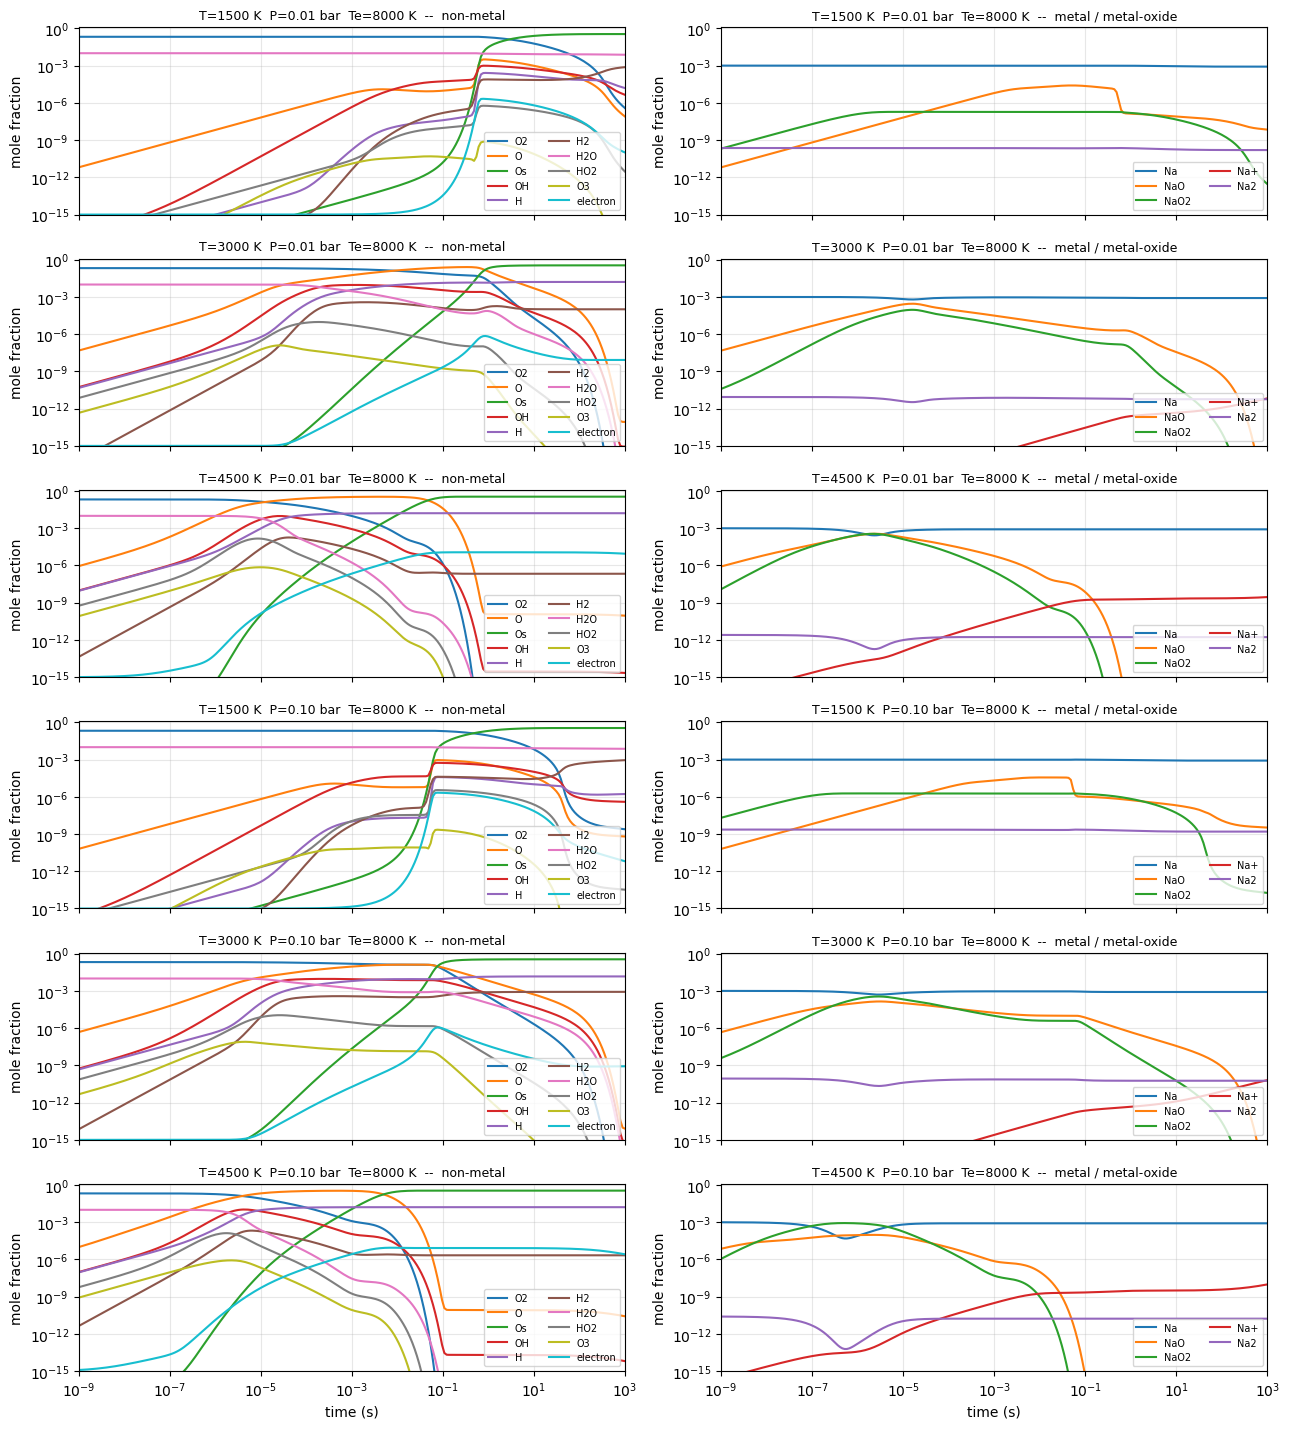

In [7]:
Y_FLOOR = 1e-30


def auto_xlim(t, X, species_indices, floor=Y_FLOOR,
              activity_low=0.02, activity_high=0.98, pad_decades=0.5):
    """Per-condition time-window picker.

    Sum |Δlog10(X)| across the plotted species to define a time-resolved
    "activity" signal, then return the time window that contains the bulk of
    the cumulative activity (default 2nd-to-98th percentile), padded by
    ``pad_decades`` on each side and clipped to the grid.
    """
    if X.shape[1] < 2:
        return t[0], t[-1]
    activity = np.zeros(X.shape[1])
    for i in species_indices:
        logx = np.log10(np.maximum(X[i], floor))
        activity[1:] += np.abs(np.diff(logx))
    total = activity.sum()
    if total <= 0.0:
        return t[0], t[-1]
    cumsum = np.cumsum(activity)
    lo_idx = int(np.argmax(cumsum >= activity_low * total))
    hi_idx = int(np.argmax(cumsum >= activity_high * total))
    t_lo = t[lo_idx] * 10 ** (-pad_decades)
    t_hi = t[hi_idx] * 10 ** (+pad_decades)
    return max(t_lo, t[0]), min(t_hi, t[-1])


nonmetal_idx = [gas.species_index(s) for s in NONMETAL_SPECIES]
metal_idx = [gas.species_index(s) for s in METAL_SPECIES]
combined_idx = nonmetal_idx + metal_idx

# Pick a single shared time window: the union of every condition's interesting
# range, so all interesting dynamics are visible at the same x-scale.
ranges = [auto_xlim(t, X, combined_idx) for (t, X) in results.values()]
global_t_lo = min(r[0] for r in ranges)
global_t_hi = max(r[1] for r in ranges)
print(f'Shared time axis: {global_t_lo:.2e} -> {global_t_hi:.2e} s')

n_rows = len(PRESSURES_BAR) * len(TEMPERATURES_K)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 2.4 * n_rows), sharex=True)

row = 0
for P_bar in PRESSURES_BAR:
    for T_K in TEMPERATURES_K:
        t, X = results[(T_K, P_bar)]
        ax_left, ax_right = axes[row, 0], axes[row, 1]

        for sp in NONMETAL_SPECIES:
            i = gas.species_index(sp)
            ax_left.plot(t, np.maximum(X[i], Y_FLOOR),
                         label=PRETTY_LABEL.get(sp, sp))
        for sp in METAL_SPECIES:
            i = gas.species_index(sp)
            ax_right.plot(t, np.maximum(X[i], Y_FLOOR),
                          label=PRETTY_LABEL.get(sp, sp))

        for ax in (ax_left, ax_right):
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.set_ylim(1e-15, 1.2)
            ax.set_xlim(global_t_lo, global_t_hi)
            ax.grid(True, which='both', alpha=0.3)
            ax.legend(fontsize=7, loc='lower right', ncol=2)
            ax.set_ylabel('mole fraction')

        ax_left.set_title(f'T={T_K:.0f} K  P={P_bar:.2f} bar  '
                          f'Te={TE_K:.0f} K  --  non-metal',
                          fontsize=9)
        ax_right.set_title(f'T={T_K:.0f} K  P={P_bar:.2f} bar  '
                           f'Te={TE_K:.0f} K  --  metal / metal-oxide',
                           fontsize=9)
        row += 1

for ax in axes[-1]:
    ax.set_xlabel('time (s)')
fig.tight_layout()
plt.show()

## What to look for

- **NaO₂ vs NaO branching with pressure**: at 0.1 bar the termolecular
  `Na + O₂ + M ⇌ NaO₂ + M` channel is faster than at 0.01 bar, so NaO₂
  should be a larger fraction of total Na-oxide at 0.1 bar.
- **Atomic O production**: O grows quickly via O₂ thermal dissociation
  even before plasma channels, especially at 4500 K.
- **NaOH appearance**: with 1% H₂O in the mixture, the new
  `NaO + H₂O ⇌ NaOH + OH` and `NaOH + H ⇌ Na + H₂O` channels (added in
  the latest `PlasmaAlkali` update) become visible in the metal-species
  panels via the OH source on the non-metal side.
- **Na ionization**: `Na+` build-up depends on the
  `Na + e⁻ ⇌ Na⁺ + 2e⁻` channel that lives off T<sub>e</sub>; with
  T<sub>e</sub> = 8000 K it is modest but non-zero.

### Health check on the mechanism

The plots reveal that the **electron mole fraction explodes from the
1e-15 seed to ≳ 0.1 within nanoseconds** — that is not physical for
T<sub>e</sub> = 8000 K. The dominant culprit is the
`O₂ + e⁻ ⇒ O₂⁺ + 2e⁻` electron-impact-ionization reaction in the
mechanism, whose rate coefficient at these conditions evaluates to
~10²³ in Cantera-internal units (many orders of magnitude above any
sensible electron-impact ionization rate). Additionally, no neutral
`NaO` or `NaO₂` accumulates above the 1e-15 plot floor at any
condition, even though the new `PlasmaAlkali` channels exist in the
chemistry. So this notebook serves a dual purpose:

1. demonstrates how to load and integrate this YAML in Cantera 3.1
   despite the CanteraWriter format issues, and
2. surfaces (via the runaway electron mole fraction and absent
   metal-oxides) that the underlying mechanism still has
   rate-coefficient unit / formulation bugs upstream — likely in
   `rmgpy/cantera.py::CanteraWriter` for the `two-temperature-plasma`
   and `electron-collision-plasma` rate types.

### Caveats

- This is a fixed-T<sub>e</sub> idealization. Real plasma experiments
  have T<sub>e</sub> set by the applied E/N field and an
  electron-energy balance; for that, the integrator above would need
  a T<sub>e</sub>(t) ODE coupled to the species ODEs (electron energy
  gain from the field minus inelastic losses to each plasma reaction).
- Cantera 3.1's `IdealGasConstPressureReactor` aborts with a
  `Phase::removeSpeciesLock` error when given a `PlasmaPhase`; the
  `solve_ivp`-based integrator above is the workaround.
- Six unbalanced electron-impact ionization reactions were dropped in
  the YAML patch step; see the `unbalanced_E_removed` list printed by
  the patch report.